In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.7 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
from scipy import stats
from arch import arch_model

In [7]:
def garch_var_report(ticker, start_date, end_date, confidence=0.95, portfolio_value=100_000):
  prices = yf.download(ticker, start_date, end_date, auto_adjust=True)
  prices = prices['Close'].dropna()
  prices = prices.squeeze()
  returns = np.log(prices/prices.shift(1)).dropna()
  returns = returns.squeeze()

  model  = arch_model(returns * 100, vol='Garch', p=1, q=1, dist='normal')
  result = model.fit(disp='off')

  omega  = result.params['omega']
  alpha  = result.params['alpha[1]']
  beta   = result.params['beta[1]']

  conditional_vol = result.conditional_volatility / 100

  z = stats.norm.ppf(1 - confidence)
  garch_var_series = abs(z * conditional_vol) * portfolio_value

  mean_return = returns.mean()
  std_return  = returns.std()
  param_var   = abs(stats.norm.ppf(1 - confidence) * std_return + mean_return) * portfolio_value

  return {
    "ticker": ticker,
    "start_date": start_date,
    "end_date": end_date,
    "returns": returns,
    "omega": omega,
    "alpha": alpha,
    "beta": beta,
    "persistence": alpha + beta,
    "conditional_vol": conditional_vol,
    "garch_var_series": garch_var_series,
    "mean_garch_var": garch_var_series.mean(),
    "param_var": param_var,
    "confidence": confidence,
    "portfolio_value": portfolio_value
}

In [8]:
g = garch_var_report("SPY", "2004-01-01", "2009-12-31")
print()
print(g["alpha"], g["beta"], g["persistence"])
print(g["mean_garch_var"], g["param_var"])

[*********************100%***********************]  1 of 1 completed


0.07373486619872219 0.9150373735417062 0.9887722397404284
1836.9160484251865 2308.0388129953526


In [13]:
def plot_garch_report(results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"{results['ticker']} | {results['start_date']} to {results['end_date']} | "
        f"Confidence: {results['confidence']*100:.0f}% | Portfolio: ${results['portfolio_value']:,}",
        fontsize=13, fontweight='bold'
    )

    # --- Plot 1: GARCH VaR vs Parametric VaR ---
    axes[0, 0].plot(results['garch_var_series'].index, results['garch_var_series'],
                    color='steelblue', linewidth=1.2, label='GARCH VaR (daily)')
    axes[0, 0].axhline(results['param_var'], color='red', linestyle='--',
                        linewidth=1.5, label=f"Parametric VaR (${results['param_var']:,.0f})")
    axes[0, 0].set_title('GARCH VaR vs Parametric VaR')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('VaR ($)')
    axes[0, 0].legend(fontsize=8)

    # --- Plot 2: Conditional Volatility ---
    axes[0, 1].plot(results['conditional_vol'].index, results['conditional_vol'],
                    color='steelblue', linewidth=1.2, label='Conditional volatility σ_t')
    axes[0, 1].axhline(results['returns'].std(), color='red', linestyle='--',
                        linewidth=1.5, label='Constant std (parametric)')
    axes[0, 1].set_title('Conditional Volatility (GARCH)')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Volatility')
    axes[0, 1].legend(fontsize=8)

    # --- Plot 3: Daily Returns with GARCH VaR band ---
    axes[1, 0].bar(results['returns'].index, results['returns'],
                   color='steelblue', alpha=0.8, label='Daily returns', width=1)
    axes[1, 0].plot(results['garch_var_series'].index, -results['garch_var_series'] / results['portfolio_value'],
                    color='red', linewidth=1.2, label='GARCH VaR threshold')
    axes[1, 0].set_title('Daily Returns vs GARCH VaR Threshold')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Log Return')
    axes[1, 0].legend(fontsize=8)

    # --- Plot 4: GARCH Parameters ---
    params = ['omega', 'alpha', 'beta']
    values = [results['omega'], results['alpha'], results['beta']]
    colors = ['steelblue', 'orange', 'red']
    axes[1, 1].bar(params, values, color=colors, alpha=0.7)
    axes[1, 1].set_title('GARCH(1,1) Parameters')
    axes[1, 1].set_ylabel('Value')
    for i, v in enumerate(values):
        axes[1, 1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)
    axes[1, 1].text(0.5, 0.92,
                    f"Persistence (α + β) = {results['persistence']:.4f}",
                    transform=axes[1, 1].transAxes,
                    ha='center', fontsize=10, color='black',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.style.use('ggplot')
    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed


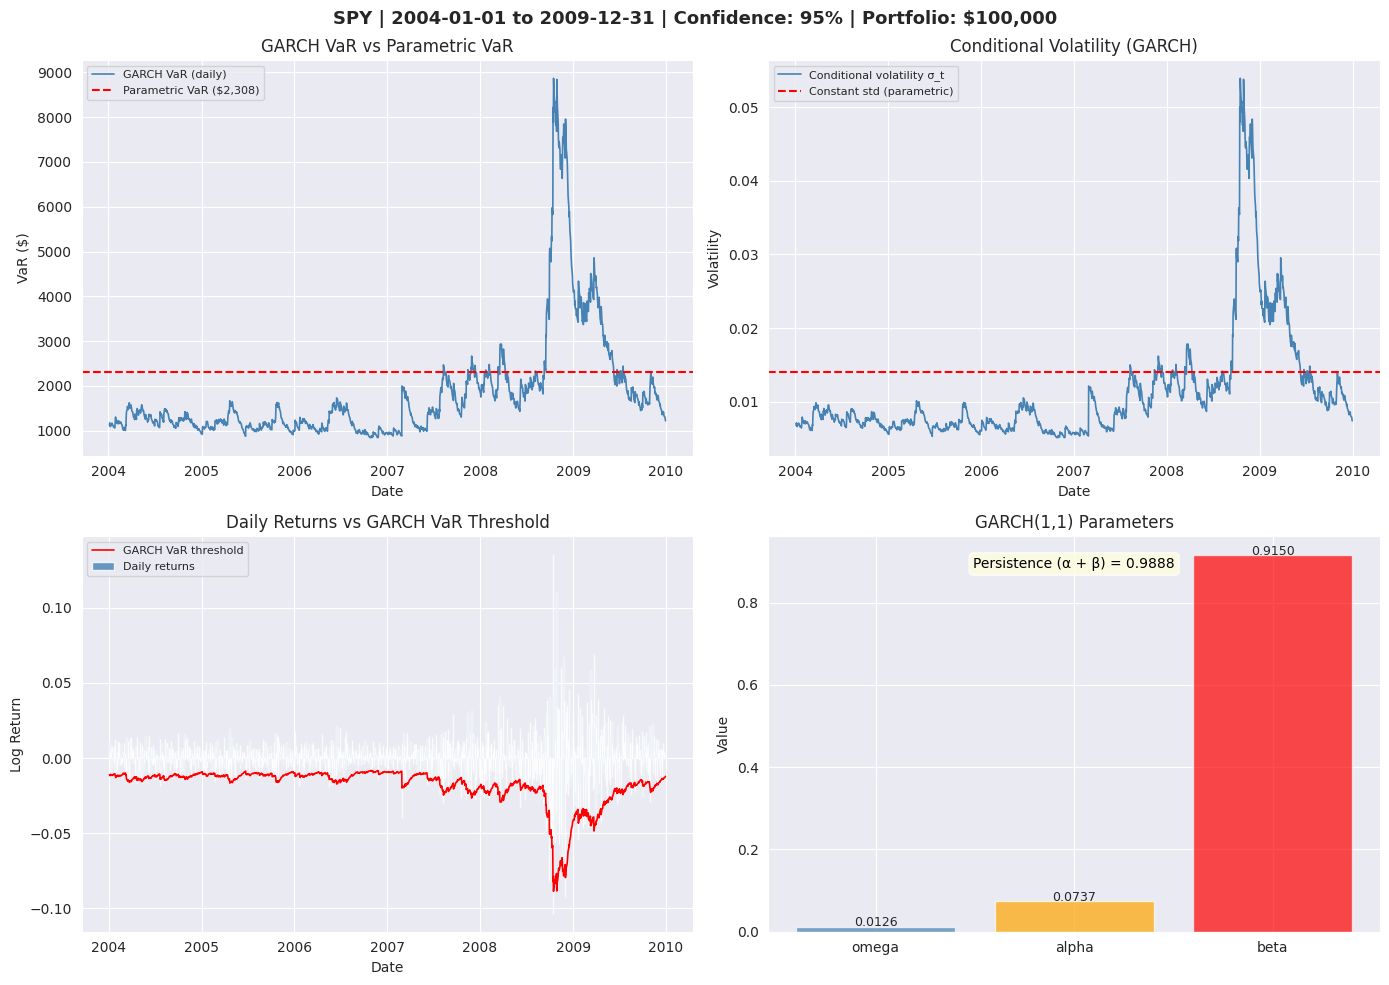

In [14]:
g = garch_var_report("SPY", "2004-01-01", "2009-12-31")
plot_garch_report(g)